In [16]:
# ============================================================================
# CÉLULA 1: Imports e Configuração
# ============================================================================

import pandas as pd
import numpy as np
import re
from collections import Counter
from itertools import combinations
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*80)
print("ANÁLISE DE FIGURAS POLÍTICAS - VERSÃO UNIFICADA V7")
print("="*80)
print("✓ Construído com Claude Sonnet 4.5 e Google Gemini 3 Pro")
print("✓ Base ampla (100+ figuras)")
print("✓ Normalização e deduplicação")
print("✓ Padrões contextuais (dep., min., etc.)")
print("✓ Visualizações avançadas")
print("✓ NER automático (descoberta)")

ANÁLISE DE FIGURAS POLÍTICAS - VERSÃO UNIFICADA V7
✓ Construído com Claude Sonnet 4.5 e Google Gemini 3 Pro
✓ Base ampla (100+ figuras)
✓ Normalização e deduplicação
✓ Padrões contextuais (dep., min., etc.)
✓ Visualizações avançadas
✓ NER automático (descoberta)


In [17]:
# ============================================================================
# CÉLULA 2: Carregar Dados (COM TRATAMENTO ROBUSTO)
# ============================================================================

print("\n[1] CARREGANDO DADOS...")

# Tentar múltiplos formatos
arquivo_excel = 'compilado_6meses.xlsx'

try:
    # Tentar CSV primeiro
    df = pd.read_csv('compilado_6meses.xlsx - Mensagens 6 meses.csv')
    print(f"✓ Dados carregados (CSV). Total: {len(df)}")
except:
    try:
        # Tentar Excel
        df = pd.read_excel(arquivo_excel)
        print(f"✓ Dados carregados (Excel). Total: {len(df)}")
    except Exception as e:
        print(f"❌ Erro ao carregar arquivo: {e}")
        print("💡 Ajuste o caminho do arquivo na linha acima")
        df = pd.DataFrame()

if not df.empty:
    # Criar texto completo
    df['Texto_Completo'] = df['Mensagem'].fillna('') + ' ' + df['Transcrição/Descrição'].fillna('')
    
    # Filtrar oposicionistas (detecção automática da coluna)
    col_oposicao = [c for c in df.columns if 'oposicionista' in c.lower()]
    
    if col_oposicao:
        col_nome = col_oposicao[0]
        df_opos = df[df[col_nome].astype(str).str.upper().str.strip() == 'SIM'].copy()
        print(f"✓ Filtro aplicado: {len(df_opos)} posts oposicionistas")
    else:
        print("⚠ Coluna 'Oposicionista' não encontrada. Analisando tudo.")
        df_opos = df.copy()
    
    print(f"✓ Período: {df_opos['Data'].min()} a {df_opos['Data'].max()}")
else:
    print("❌ Não foi possível carregar os dados. Verifique o caminho do arquivo.")


[1] CARREGANDO DADOS...
✓ Dados carregados (Excel). Total: 1579
✓ Filtro aplicado: 815 posts oposicionistas
✓ Período: 2023-02-01 10:37:08 a 2023-07-31 19:48:29


In [18]:
# ============================================================================
# CÉLULA 3: Base de Figuras Conhecidas (REORGANIZADA - 100+ figuras)
# ============================================================================
# ORGANIZAÇÃO:
# 1. Governo Federal - Administração Lula (atual)
# 2. Oposição ao Governo Federal
# 3. Instituições da República (Judiciário, Legislativo, Órgãos de Controle)
# 4. Partidos Políticos
# 5. Política Regional (Mato Grosso)
# ============================================================================

print("\n[2] DEFININDO BASE DE FIGURAS CONHECIDAS...")

figuras_categorias = {
    # ========================================================================
    # 1. GOVERNO FEDERAL - ADMINISTRAÇÃO LULA (2023-atual)
    # ========================================================================
    
    'Governo_Federal_Presidente': {
        'Lula': r'\b(lula|luiz inacio|lula da silva|nine|presidiario|lul4|atual presidente|atual mandatário)\b',
        'Dilma Rousseff': r'\b(dilma rousseff|dilma|dilma roussef|dilmãe)\b',
        'Geraldo Alckmin': r'\b(geraldo alckmin|alckmin|vice presidente)\b',
    },
    
    'Governo_Federal_Familia_Circulo': {
        'Janja': r'\b(janja|rosangela janja|canja|primeira dama)\b',
    },
    
    'Governo_Federal_Ministerios': {
        'Fernando Haddad': r'\b(haddad|fernando haddad|taxad|ministro da fazenda)\b',
        'Flavio Dino': r'\b(flavio dino|dino|flávio dino|ministro da justiça)\b',
        'Marina Silva': r'\b(marina silva|marina|ministra do meio ambiente)\b',
        'Camilo Santana': r'\b(camilo santana|camilo|ministro da educação)\b',
        'Simone Tebet': r'\b(simone tebet|tebet|ministra do planejamento)\b',
        'Rui Costa': r'\b(rui costa|ministro da casa civil)\b',
        'Alexandre Padilha': r'\b(alexandre padilha|padilha|ministro das relações institucionais)\b',
        'Paulo Pimenta': r'\b(paulo pimenta|pimenta|ministro da secom)\b',
        'Mauro Vieira': r'\b(mauro vieira|ministro das relações exteriores)\b',
        'José Múcio': r'\b(jose mucio|múcio|mucio|josé múcio|ministro da defesa)\b',
        'Carlos Lupi': r'\b(carlos lupi|lupi|ministro da previdência)\b',
        'Nísia Trindade': r'\b(nisia trindade|nísia trindade|nisia|nísia|ministra da saúde)\b',
        'Luiz Marinho': r'\b(luiz marinho|ministro do trabalho)\b',
        'Wellington Dias': r'\b(wellington dias|ministro do desenvolvimento social)\b',
        'Margareth Menezes': r'\b(margareth menezes|margareth|menezes|ministra da cultura)\b',
        'Ana Moser': r'\b(ana moser|moser|mozer|ministra do esporte)\b',
        'Anielle Franco': r'\b(anielle franco|anielle|aniele|ministra da igualdade racial)\b',
        'Sônia Guajajara': r'\b(sonia guajajara|sônia guajajara|guajajara|ministra dos povos indígenas)\b',
        'Cida Gonçalves': r'\b(cida gonçalves|cida goncalves|ministra das mulheres)\b',
        'Silvio Almeida': r'\b(silvio almeida|ministro dos direitos humanos)\b',
        'Waldez Góes': r'\b(waldez goes|waldez góes|ministro da integração)\b',
        'Márcio França': r'\b(marcio franca|márcio frança|ministro do empreendedorismo)\b',
        'Renan Filho': r'\b(renan filho|ministro dos transportes)\b',
        'Jader Filho': r'\b(jader filho|jader|ministro das cidades)\b',
        'Juscelino Filho': r'\b(juscelino filho|juscelino|ministro das comunicações)\b',
        'Alexandre Silveira': r'\b(alexandre silveira|ministro de minas e energia)\b',
        'Carlos Fávaro': r'\b(carlos favaro|fávaro|favaro|ministro da agricultura)\b',
        'Paulo Teixeira': r'\b(paulo teixeira|teixeira|ministro do desenvolvimento agrário)\b',
        'André de Paula': r'\b(andre de paula|andré de paula|ministro da pesca)\b',
        'Luciana Santos': r'\b(luciana santos|ministra da ciência e tecnologia)\b',
        'Esther Dweck': r'\b(esther dweck|ester dweck|ministra da gestão)\b',
        'Vinícius Carvalho': r'\b(vinicius carvalho|vinícius carvalho|vinicius marques|controlador geral)\b',
        'Márcio Macêdo': r'\b(marcio macedo|márcio macêdo|ministro da secretaria geral)\b',
        'Jorge Messias': r'\b(jorge messias|bessias|advogado geral da união)\b',
        'Gonçalves Dias': r'\b(gonçalves dias|goncalves dias|general dias|ministro do gsi| g. dias)\b',
        'Marcos Amaro': r'\b(marcos amaro|general amaro|marcos antônio amaro|secretário executivo)\b',
        'Daniela Carneiro': r'\b(daniela carneiro|daniela do waguinho|ministra do turismo)\b',
        'Celso Sabino': r'\b(celso sabino|sabino|ministro do turismo)\b',
    },
    
    'Governo_Federal_Entidade': {
        'Governo Federal': r'\b(governo federal|governo lula|atual governo|administração lula)\b',
    },

    'Governo_Federal_Relacoes_Exteriores': {
        'Nicolás Maduro': r'\b(nicolas maduro|maduro|presidente da venezuela|ditador venezuelano)\b',
        'Cuba': r'\b(cuba|regime cubano)\b',
        'Daniel Ortega': r'\b(daniel ortega|nicaragua|presidente da nicaragua|ditador da nicaragua)\b',

    },
    
    # ========================================================================
    # 2. OPOSIÇÃO AO GOVERNO FEDERAL
    # ========================================================================
    
    'Oposicao_Liderancas_Principais': {
        'Jair Bolsonaro': r'\b(bolsonaro|jair bolsonaro|capitao|mito|ex presidente bolsonaro)\b',
        'Michelle Bolsonaro': r'\b(michelle bolsonaro|michelle)\b',
    },
    
    'Oposicao_Familia_Bolsonaro': {
        'Eduardo Bolsonaro': r'\b(eduardo bolsonaro|bananinha|deputado eduardo)\b',
        'Flávio Bolsonaro': r'\b(flavio bolsonaro|senador flavio)\b',
        'Carlos Bolsonaro': r'\b(carlos bolsonaro|carluxo|vereador carlos)\b',
    },
    
    'Oposicao_Legislativo': {
        'Nikolas Ferreira': r'\b(nikolas ferreira|nikolas|chupetinha)\b',
        'Carla Zambelli': r'\b(carla zambelli|zambelli)\b',
        'Bia Kicis': r'\b(bia kicis|bia)\b',
        'Kim Kataguiri': r'\b(kim kataguiri|kim)\b',
        'Marcel van Hattem': r'\b(marcel van hattem|marcel)\b',
        'Zé Trovão': r'\b(ze trovao|zé trovão)\b',
    },
    
    'Oposicao_Ex_Governo_Bolsonaro': {
        'Sérgio Moro': r'\b(sergio moro|moro|ex ministro moro)\b',
        'Deltan Dallagnol': r'\b(deltan dallagnol|deltan)\b',
        'Anderson Ramagem': r'\b(anderson ramagem|ramagem|ramage)\b',
    },
    
    # ========================================================================
    # 3. INSTITUIÇÕES DA REPÚBLICA
    # ========================================================================
    
    'Institucoes_STF': {
        'STF': r'\b(stf|supremo tribunal federal|suprema corte)\b',
        'Alexandre de Moraes': r'\b(alexandre de moraes|moraes|xandao|xandão|calvo|ministro alexandre)\b',
        'Gilmar Mendes': r'\b(gilmar mendes|gilmar|ministro gilmar)\b',
        'Dias Toffoli': r'\b(dias toffoli|toffoli|ministro toffoli)\b',
        'Luis Roberto Barroso': r'\b(barroso|luis roberto barroso|luís roberto barroso|presidente do stf)\b',
        'Cristiano Zanin': r'\b(zanin|cristiano zanin|ministro zanin)\b',
        'André Mendonça': r'\b(andre mendonça|andré mendonça|mendonça|mendonca|ministro andre|terrivelmente evangelico)\b',
        'Cármen Lúcia': r'\b(carmen lucia|cármen lúcia|ministra carmen)\b',
        'Rosa Weber': r'\b(rosa weber|ministra rosa)\b',
        'Ricardo Lewandowski': r'\b(lewandowski|ricardo lewandowski|ministro lewandowski)\b',
        'Edson Fachin': r'\b(fachin|edson fachin|ministro fachin)\b',
        'Luiz Fux': r'\b(fux|luiz fux|ministro fux)\b',
        'Kassio Nunes Marques': r'\b(kassio nunes marques|kassio|nunes marques|ministro kassio)\b',
    },
    
    'Institucoes_Justica_Eleitoral': {
        'TSE': r'\b(tse|tribunal superior eleitoral)\b',
    },
    
    'Institucoes_Legislativo_Presidencias': {
        'Arthur Lira': r'\b(arthur lira|lira|presidente da camara)\b',
        'Rodrigo Pacheco': r'\b(rodrigo pacheco|pacheco|presidente do senado)\b',
    },
    
    'Institucoes_Legislativo_Parlamentares': {
        'Gleisi Hoffmann': r'\b(gleisi hoffmann|gleisi|amante|narizinho|presidente do pt)\b',
        'Randolfe Rodrigues': r'\b(randolfe rodrigues|randolfe|senador randolfe)\b',
        'Lindbergh Farias': r'\b(lindbergh farias|lindbergh|lindemberg|senador lindbergh)\b',
        'Jaques Wagner': r'\b(jaques wagner|senador jaques)\b',
        'Renan Calheiros': r'\b(renan calheiros|senador renan)\b',
        'Orlando Silva': r'\b(orlando silva|deputado orlando)\b',
    },
    
    # ========================================================================
    # 4. PARTIDOS POLÍTICOS
    # ========================================================================
    
    'Partidos_Governistas': {
        'PT': r'\b(pt|partido dos trabalhadores|petistas|petista|petralha)\b',
        'PSB': r'\b(psb|partido socialista brasileiro)\b',
        'PDT': r'\b(pdt)\b',
        'PCdoB': r'\b(pcdob|pc do b)\b',
        'PV': r'\b(partido verde)\b',
        'PSOL': r'\b(psol)\b',
    },
    
    'Partidos_Oposicao': {
        'PL': r'\b(pl|partido liberal)\b',
    },
    
    'Partidos_Centro': {
        'MDB': r'\b(mdb)\b',
        'PSDB': r'\b(psdb|tucano|tucanos)\b',
    },
    
    # ========================================================================
    # 5. POLÍTICA REGIONAL (MATO GROSSO)
    # ========================================================================
    
    'Mato_Grosso_Executivo': {
        'Mauro Mendes': r'\b(mauro mendes|mauro|governador mauro)\b',
        'Emanuel Pinheiro': r'\b(emanuel pinheiro|emanuel|prefeito emanuel)\b',
        'Emanuelzinho': r'\bemanuelzinho\b',
    },
    
    'Mato_Grosso_Politicos': {
        'Silval Barbosa': r'\b(silval barbosa|silval)\b',
        'Pedro Taques': r'\b(pedro taques|taques)\b',
        'Lúdio Cabral': r'\b(ludio cabral|ludio)\b',
        'Edna Sampaio': r'\b(edna sampaio|edna)\b',
        'Blairo Maggi': r'\b(blairo maggi|maggi)\b',
    }
}

# Contar figuras por categoria principal
categorias_principais = {
    'Governo Federal': ['Governo_Federal_Presidente', 'Governo_Federal_Familia_Circulo', 
                        'Governo_Federal_Ministerios', 'Governo_Federal_Entidade', 'Governo_Federal_Relacoes_Exteriores'],
    'Oposição': ['Oposicao_Liderancas_Principais', 'Oposicao_Familia_Bolsonaro', 
                 'Oposicao_Legislativo', 'Oposicao_Ex_Governo_Bolsonaro'],
    'Instituições': ['Institucoes_STF', 'Institucoes_Justica_Eleitoral', 
                     'Institucoes_Legislativo_Presidencias', 'Institucoes_Legislativo_Parlamentares'],
    'Partidos': ['Partidos_Governistas', 'Partidos_Oposicao', 'Partidos_Centro'],
    'Regional': ['Mato_Grosso_Executivo', 'Mato_Grosso_Politicos']
}

# Contar figuras
total_figuras = sum(len(v) for v in figuras_categorias.values())
print(f"✓ Base de figuras: {total_figuras} figuras em {len(figuras_categorias)} subcategorias")
print(f"✓ Organizadas em 5 categorias principais:\n")

for cat_principal, subcats in categorias_principais.items():
    total_cat = sum(len(figuras_categorias[subcat]) for subcat in subcats if subcat in figuras_categorias)
    print(f"   📂 {cat_principal}: {total_cat} figuras")
    for subcat in subcats:
        if subcat in figuras_categorias:
            print(f"      ├─ {subcat.replace('_', ' ')}: {len(figuras_categorias[subcat])} figuras")



[2] DEFININDO BASE DE FIGURAS CONHECIDAS...
✓ Base de figuras: 99 figuras em 18 subcategorias
✓ Organizadas em 5 categorias principais:

   📂 Governo Federal: 46 figuras
      ├─ Governo Federal Presidente: 3 figuras
      ├─ Governo Federal Familia Circulo: 1 figuras
      ├─ Governo Federal Ministerios: 38 figuras
      ├─ Governo Federal Entidade: 1 figuras
      ├─ Governo Federal Relacoes Exteriores: 3 figuras
   📂 Oposição: 14 figuras
      ├─ Oposicao Liderancas Principais: 2 figuras
      ├─ Oposicao Familia Bolsonaro: 3 figuras
      ├─ Oposicao Legislativo: 6 figuras
      ├─ Oposicao Ex Governo Bolsonaro: 3 figuras
   📂 Instituições: 22 figuras
      ├─ Institucoes STF: 13 figuras
      ├─ Institucoes Justica Eleitoral: 1 figuras
      ├─ Institucoes Legislativo Presidencias: 2 figuras
      ├─ Institucoes Legislativo Parlamentares: 6 figuras
   📂 Partidos: 9 figuras
      ├─ Partidos Governistas: 6 figuras
      ├─ Partidos Oposicao: 1 figuras
      ├─ Partidos Centro: 2 f

In [19]:
# ============================================================================
# CÉLULA 4: Padrões Contextuais (NOVO - Com abreviações)
# ============================================================================

print("\n[3] DEFININDO PADRÕES CONTEXTUAIS...")

padroes_contextuais = [
    (r'\b(presidente|pres\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_presidente'),
    (r'\b(ministro|ministra|min\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_ministro'),
    (r'\b(governador|governadora|gov\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_governador'),
    (r'\b(prefeito|prefeita|pref\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_prefeito'),
    (r'\b(senador|senadora|sen\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_senador'),
    (r'\b(deputado|deputada|dep\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_deputado'),
    (r'\b(vereador|vereadora|ver\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_vereador'),
    (r'\b(ex-presidente|ex-pres\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)?)', 'cargo_ex_presidente'),
]

print(f"✓ {len(padroes_contextuais)} padrões contextuais definidos")
print("   Captura: 'dep. Maria', 'min. Haddad', 'presidente Lula', etc.")


[3] DEFININDO PADRÕES CONTEXTUAIS...
✓ 8 padrões contextuais definidos
   Captura: 'dep. Maria', 'min. Haddad', 'presidente Lula', etc.


In [20]:
# ============================================================================
# CÉLULA 5: Função de Normalização (Elimina duplicatas)
# ============================================================================

def normalizar_figura(nome_figura, categoria=''):
    """
    Normaliza nomes de figuras para evitar duplicatas.
    Mapeia variações para forma canônica.
    """
    # Remover indicadores de cargo
    if '(cargo_' in nome_figura:
        nome_limpo = nome_figura.split(' (cargo_')[0].strip()
    else:
        nome_limpo = nome_figura.strip()
    
    # Dicionário de normalizações (EXPANDIDO)
    normalizacoes = {
        # Executivo
        'lula': 'Lula',
        'luiz inacio': 'Lula',
        'lula da silva': 'Lula',
        'nine': 'Lula',
        'presidiario': 'Lula',
        'atual mandatário': 'Lula',
        'atual presidente': 'Lula',
        'bolsonaro': 'Jair Bolsonaro',
        'jair bolsonaro': 'Jair Bolsonaro',
        'capitao': 'Jair Bolsonaro',
        'mito': 'Jair Bolsonaro',
        'janja': 'Janja',
        'rosangela janja': 'Janja',
        'canja': 'Janja',
        'ministro da fazenda de Lula': 'Fernando Haddad',
        'haddad': 'Fernando Haddad',
        'fernando haddad': 'Fernando Haddad',
        'taxad': 'Fernando Haddad',
        'dino': 'Flavio Dino',
        'flavio dino': 'Flavio Dino',
        'ministro dino': 'Flavio Dino', 
        'flávio dino': 'Flavio Dino',
        'marina': 'Marina Silva',
        'marina silva': 'Marina Silva',
        
        # Judiciário
        'moraes': 'Alexandre de Moraes',
        'alexandre': 'Alexandre de Moraes',
        'alexandre de moraes': 'Alexandre de Moraes',
        'xandao': 'Alexandre de Moraes',
        'xandão': 'Alexandre de Moraes',
        'calvo': 'Alexandre de Moraes',
        'gilmar': 'Gilmar Mendes',
        'gilmar mendes': 'Gilmar Mendes',
        'barroso': 'Luis Roberto Barroso',
        'luis roberto barroso': 'Luis Roberto Barroso',
        'zanin': 'Cristiano Zanin',
        'cristiano zanin': 'Cristiano Zanin',
        
        # Legislativo
        'lira': 'Arthur Lira',
        'arthur lira': 'Arthur Lira',
        'pacheco': 'Rodrigo Pacheco',
        'rodrigo pacheco': 'Rodrigo Pacheco',
        'nikolas': 'Nikolas Ferreira',
        'nikolas ferreira': 'Nikolas Ferreira',
        'chupetinha': 'Nikolas Ferreira',
        'gleisi': 'Gleisi Hoffmann',
        'gleisi hoffmann': 'Gleisi Hoffmann',
        'zambelli': 'Carla Zambelli',
        'carla zambelli': 'Carla Zambelli',
        'eduardo bolsonaro': 'Eduardo Bolsonaro',
        'bananinha': 'Eduardo Bolsonaro',
        'moro': 'Sérgio Moro',
        'sergio moro': 'Sérgio Moro',
        'sérgio moro': 'Sérgio Moro',
        'bia': 'Bia Kicis',
        'bia kicis': 'Bia Kicis',
        
        # Partidos
        'pt': 'PT',
        'petistas': 'PT',
        'petista': 'PT',
        'petralha': 'PT',
        'pl': 'PL',
        
        # MT
        'mauro': 'Mauro Mendes',
        'mauro mendes': 'Mauro Mendes',
        'emanuel': 'Emanuel Pinheiro',
        'emanuel pinheiro': 'Emanuel Pinheiro',
        'silval': 'Silval Barbosa',
        'silval barbosa': 'Silval Barbosa',
    }
    
    nome_lower = nome_limpo.lower()
    
    if nome_lower in normalizacoes:
        return normalizacoes[nome_lower]
    
    # Retornar capitalizado
    return nome_limpo.title() if nome_limpo else nome_limpo

print("\n✓ Função de normalização criada")
print("   Remove duplicatas: 'Lula', 'lula', 'Nine', 'presidente Lula' → 'Lula'")


✓ Função de normalização criada
   Remove duplicatas: 'Lula', 'lula', 'Nine', 'presidente Lula' → 'Lula'


In [21]:
# ============================================================================
# CÉLULA 6: Identificação com Normalização (CORE DO SISTEMA)
# ============================================================================

print("\n[4] IDENTIFICANDO FIGURAS (com normalização)...")

resultados = []
total_duplicatas_removidas = 0

for idx, row in df_opos.iterrows():
    texto = row['Texto_Completo']
    texto_lower = texto.lower()
    
    figuras_post = []
    categorias_post = []
    
    # Buscar na base conhecida
    for categoria, figuras_dict in figuras_categorias.items():
        for figura, padrao in figuras_dict.items():
            if re.search(padrao, texto_lower, re.IGNORECASE):
                figuras_post.append(figura)
                categorias_post.append(categoria)
    
    # Buscar com padrões contextuais
    for padrao, tipo in padroes_contextuais:
        matches = re.finditer(padrao, texto)
        for match in matches:
            nome = match.group(2).strip()
            if nome and len(nome) > 3:
                figura_descoberta = f"{nome} ({tipo})"
                figuras_post.append(figura_descoberta)
    
    # NORMALIZAR E REMOVER DUPLICATAS
    if figuras_post:
        # Normalizar
        figuras_normalizadas = [normalizar_figura(fig) for fig in figuras_post]
        
        # Remover duplicatas
        figuras_unicas = []
        figuras_vistas = set()
        
        for fig in figuras_normalizadas:
            fig_lower = fig.lower()
            if fig_lower not in figuras_vistas:
                figuras_unicas.append(fig)
                figuras_vistas.add(fig_lower)
        
        # Contar duplicatas removidas
        if len(figuras_post) > len(figuras_unicas):
            total_duplicatas_removidas += (len(figuras_post) - len(figuras_unicas))
        
        # Categorias únicas
        categorias_unicas = sorted(set(categorias_post))
        
        resultados.append({
            'Perfil': row['Perfil'],
            'Data': row['Data'],
            'Link': row['Link do Post'],
            'Mensagem': row['Mensagem'],
            'Texto_Completo': row['Transcrição/Descrição'],
            'Num_Figuras': len(figuras_unicas),
            'Figuras': ', '.join(sorted(figuras_unicas)),
            'Categorias': ', '.join(categorias_unicas),
            'Figuras_Original': ', '.join(figuras_post)  # Debug
        })

df_resultados = pd.DataFrame(resultados)

print(f"✓ Posts com figuras: {len(df_resultados)} ({len(df_resultados)/len(df_opos)*100:.1f}%)")
print(f"✓ Duplicatas removidas: {total_duplicatas_removidas}")



[4] IDENTIFICANDO FIGURAS (com normalização)...
✓ Posts com figuras: 722 (88.6%)
✓ Duplicatas removidas: 163


In [22]:
# ============================================================================
# CÉLULA 7: Análise de Frequência (UNIFICADA)
# ============================================================================

print("\n[5] RANKING DE FIGURAS (NORMALIZADO):")
print("="*80)

# Contar figuras
todas_figuras = []
for figuras_str in df_resultados['Figuras']:
    todas_figuras.extend(figuras_str.split(', '))

contador = Counter(todas_figuras)

print(f"\nTotal de figuras únicas: {len(contador)}")
print("\nTop 30:")
for i, (figura, freq) in enumerate(contador.most_common(30), 1):
    pct = freq / len(df_opos) * 100
    print(f"   {i:2d}. {figura:35s} : {freq:4d} menções ({pct:5.1f}%)")



[5] RANKING DE FIGURAS (NORMALIZADO):

Total de figuras únicas: 149

Top 30:
    1. Lula                                :  511 menções ( 62.7%)
    2. Jair Bolsonaro                      :  218 menções ( 26.7%)
    3. PT                                  :  196 menções ( 24.0%)
    4. Governo Federal                     :  156 menções ( 19.1%)
    5. PL                                  :   84 menções ( 10.3%)
    6. Flavio Dino                         :   46 menções (  5.6%)
    7. Dilma Rousseff                      :   38 menções (  4.7%)
    8. Stf                                 :   38 menções (  4.7%)
    9. Nicolás Maduro                      :   34 menções (  4.2%)
   10. Fernando Haddad                     :   25 menções (  3.1%)
   11. Janja                               :   23 menções (  2.8%)
   12. Sérgio Moro                         :   20 menções (  2.5%)
   13. Gonçalves Dias                      :   17 menções (  2.1%)
   14. Michelle Bolsonaro                  :   15 m

In [23]:
# ============================================================================
# CÉLULA 8: Análise por Categoria
# ============================================================================

print("\n[6] DISTRIBUIÇÃO POR CATEGORIA:")
print("="*80)

# Contar posts por categoria
todas_categorias = []
for cat_str in df_resultados['Categorias']:
    todas_categorias.extend(cat_str.split(', '))

contador_cat = Counter(todas_categorias)

print("\nPosts por categoria (um post pode ter múltiplas):")
for cat, freq in contador_cat.most_common():
    pct = freq / len(df_opos) * 100
    print(f"   {cat:25s} : {freq:4d} posts ({pct:5.1f}%)")


[6] DISTRIBUIÇÃO POR CATEGORIA:

Posts por categoria (um post pode ter múltiplas):
   Governo_Federal_Presidente :  519 posts ( 63.7%)
   Oposicao_Liderancas_Principais :  219 posts ( 26.9%)
   Partidos_Governistas      :  203 posts ( 24.9%)
   Governo_Federal_Entidade  :  156 posts ( 19.1%)
   Governo_Federal_Ministerios :  142 posts ( 17.4%)
   Partidos_Oposicao         :   84 posts ( 10.3%)
   Institucoes_STF           :   56 posts (  6.9%)
   Governo_Federal_Relacoes_Exteriores :   43 posts (  5.3%)
   Oposicao_Ex_Governo_Bolsonaro :   28 posts (  3.4%)
   Governo_Federal_Familia_Circulo :   23 posts (  2.8%)
   Institucoes_Legislativo_Parlamentares :   22 posts (  2.7%)
   Institucoes_Legislativo_Presidencias :   15 posts (  1.8%)
   Oposicao_Legislativo      :   13 posts (  1.6%)
   Institucoes_Justica_Eleitoral :   13 posts (  1.6%)
   Mato_Grosso_Executivo     :   11 posts (  1.3%)
   Partidos_Centro           :    5 posts (  0.6%)
   Oposicao_Familia_Bolsonaro :    4 posts ( 

In [24]:
# ============================================================================
# CÉLULA 9: Análise por Parlamentar
# ============================================================================

print("\n[7] FIGURAS POR PARLAMENTAR:")
print("="*80)

for parlamentar in df_opos['Perfil'].unique():
    posts_parl = df_resultados[df_resultados['Perfil'] == parlamentar]
    
    if len(posts_parl) > 0:
        figuras_parl = []
        for figuras_str in posts_parl['Figuras']:
            figuras_parl.extend(figuras_str.split(', '))
        
        contador_parl = Counter(figuras_parl)
        
        print(f"\n{parlamentar}:")
        print(f"   Posts: {len(posts_parl)}")
        print(f"   Top 10:")
        for fig, freq in contador_parl.most_common(10):
            print(f"      {freq:3d}x - {fig}")


[7] FIGURAS POR PARLAMENTAR:

Abílio Brunini:
   Posts: 60
   Top 10:
       39x - Lula
       22x - Jair Bolsonaro
       22x - PT
       22x - Governo Federal
       14x - PL
        9x - Flavio Dino
        6x - Psol
        5x - Dilma Rousseff
        4x - Emanuelzinho
        4x - Lindbergh Farias

Amália Barros:
   Posts: 79
   Top 10:
       64x - Lula
       27x - Governo Federal
       24x - Jair Bolsonaro
       14x - PT
       14x - PL
        5x - Flavio Dino
        4x - Stf
        4x - Michelle Bolsonaro
        3x - Arthur Lira
        3x - Tse

Coronel Assis:
   Posts: 98
   Top 10:
       63x - Lula
       41x - Governo Federal
       19x - Flavio Dino
       14x - Jair Bolsonaro
       12x - PL
       12x - PT
       11x - Nicolás Maduro
        6x - Gonçalves Dias
        4x - Stf
        4x - Dilma Rousseff

Coronel Fernanda:
   Posts: 19
   Top 10:
       12x - PL
        6x - Jair Bolsonaro
        3x - Lula
        2x - PT
        2x - Bia Kicis
        1x - Fl

In [25]:
# ============================================================================
# CÉLULA 10: Co-ocorrências (CORRIGIDA)
# ============================================================================

print("\n[8] CO-OCORRÊNCIAS:")
print("="*80)

coocorrencias = []

for figuras_str in df_resultados['Figuras']:
    figuras_lista = figuras_str.split(', ')
    
    if len(figuras_lista) >= 2:
        # Usar combinations para gerar todos os pares
        for par in combinations(sorted(figuras_lista), 2):
            coocorrencias.append(par)

contador_pares = Counter(coocorrencias)

print("\nTop 25 pares:")
for i, (par, freq) in enumerate(contador_pares.most_common(25), 1):
    if freq >= 3:
        print(f"   {i:2d}. {freq:3d}x - {par[0]} + {par[1]}")


[8] CO-OCORRÊNCIAS:

Top 25 pares:
    1. 157x - Jair Bolsonaro + Lula
    2. 132x - Lula + PT
    3. 123x - Governo Federal + Lula
    4.  78x - Jair Bolsonaro + PT
    5.  49x - Governo Federal + Jair Bolsonaro
    6.  41x - Governo Federal + PT
    7.  41x - Lula + PL
    8.  31x - Dilma Rousseff + Lula
    9.  30x - Jair Bolsonaro + PL
   10.  30x - Lula + Nicolás Maduro
   11.  28x - Lula + Stf
   12.  26x - Flavio Dino + Lula
   13.  23x - Dilma Rousseff + Jair Bolsonaro
   14.  19x - PL + PT
   15.  18x - Janja + Lula
   16.  17x - Dilma Rousseff + PT
   17.  16x - Governo Federal + PL
   18.  16x - Lula + Sérgio Moro
   19.  14x - Jair Bolsonaro + Michelle Bolsonaro
   20.  13x - Fernando Haddad + Lula
   21.  13x - Flavio Dino + PT
   22.  13x - Flavio Dino + Jair Bolsonaro
   23.  13x - Jair Bolsonaro + Nicolás Maduro
   24.  13x - Jair Bolsonaro + Stf
   25.  12x - Cristiano Zanin + Lula



[9] GERANDO VISUALIZAÇÕES...


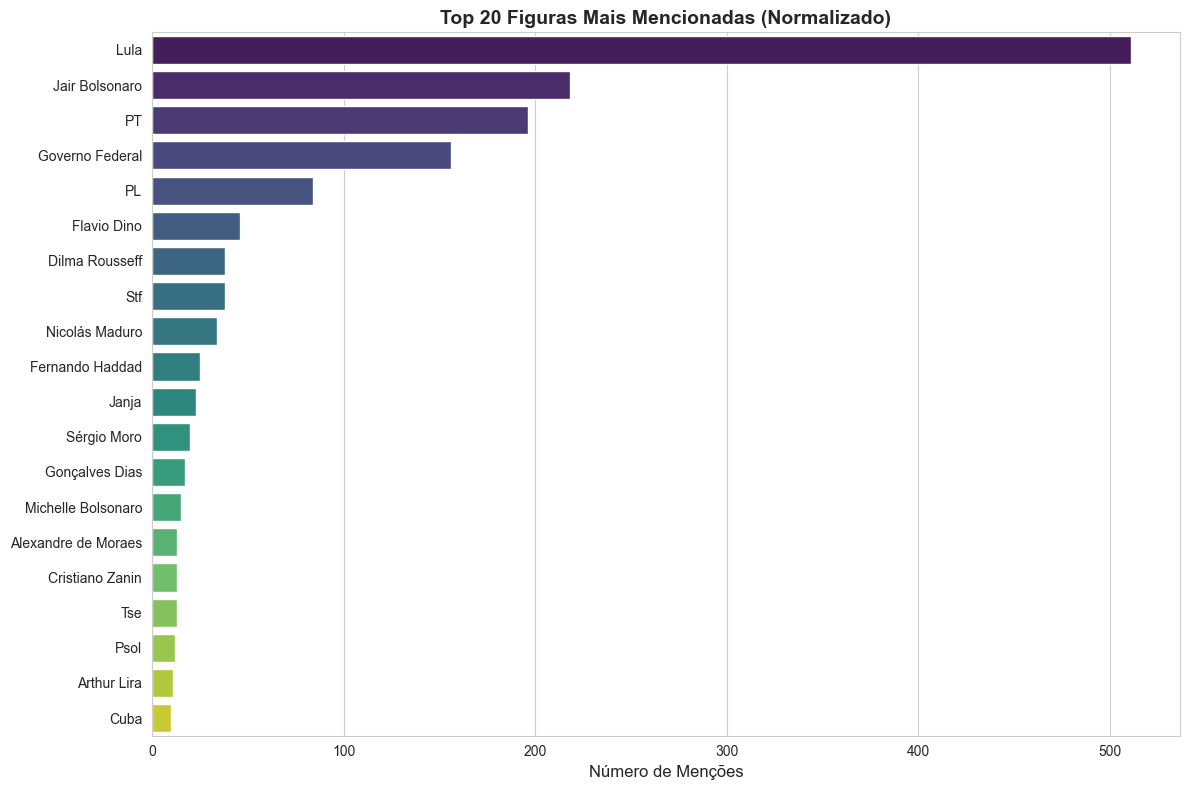

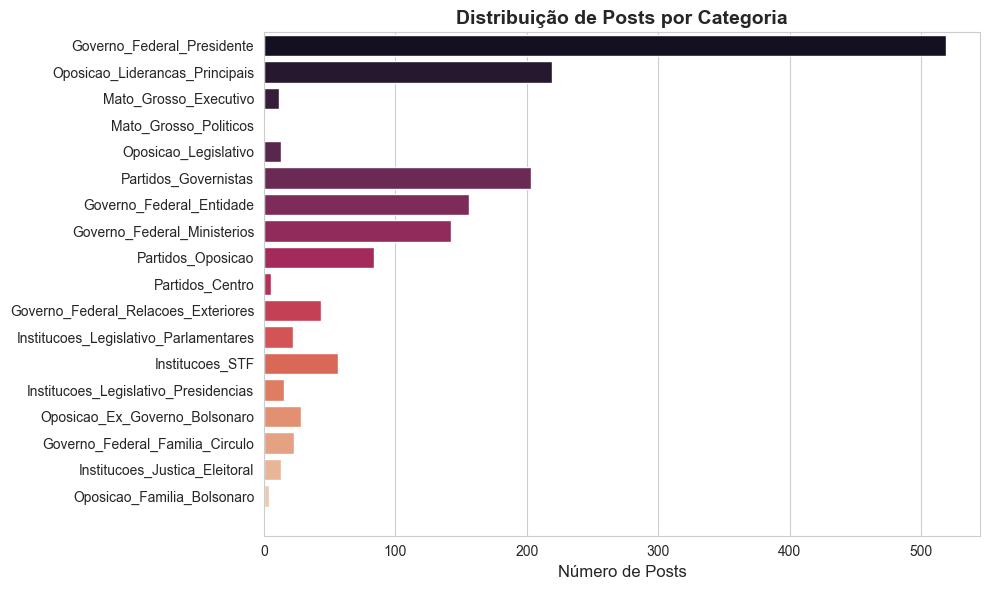

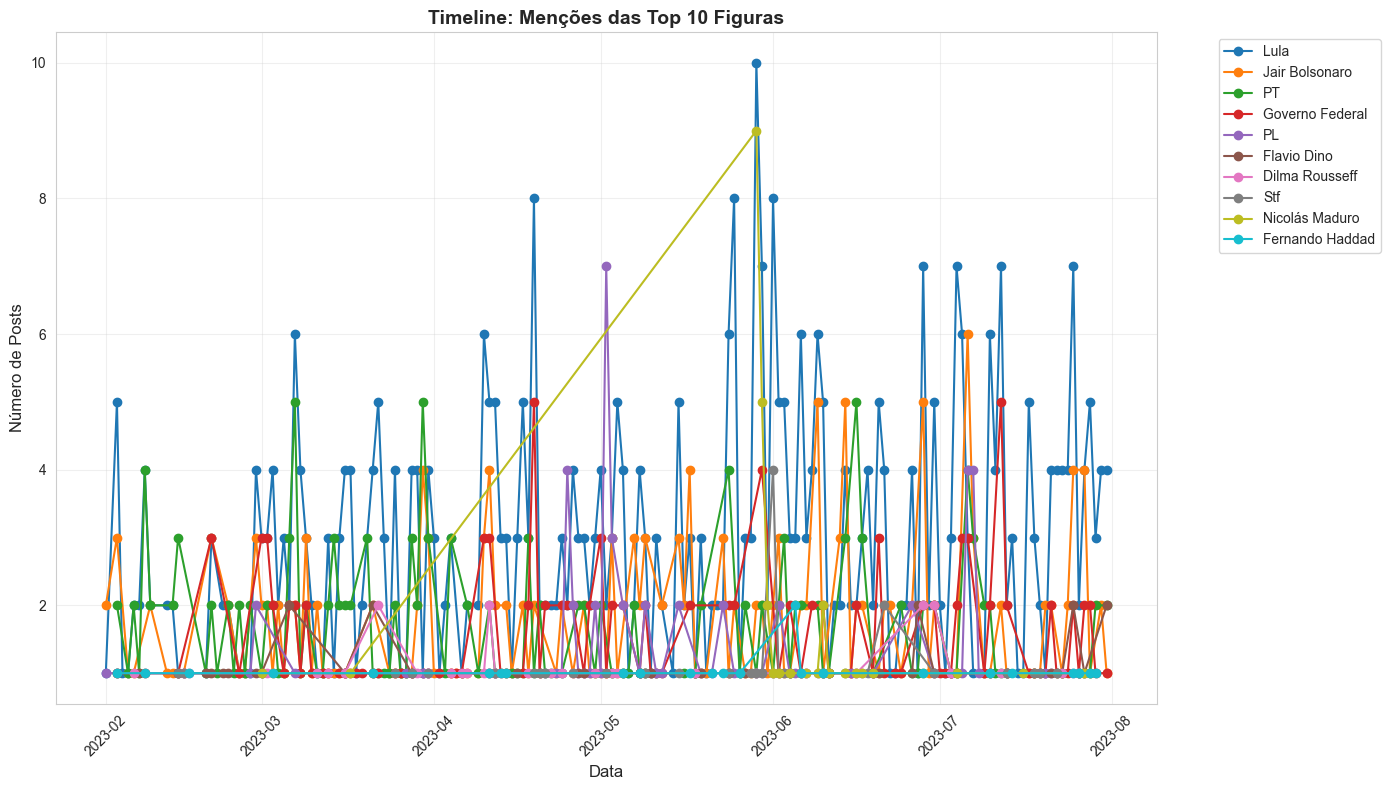

✓ Visualizações geradas


In [28]:
# ============================================================================
# CÉLULA 11: Visualizações
# ============================================================================

print("\n[9] GERANDO VISUALIZAÇÕES...")

# Gráfico 1: Top 20 Figuras
plt.figure(figsize=(12, 8))
top_20 = contador.most_common(20)
nomes = [f[0] for f in top_20]
valores = [f[1] for f in top_20]

sns.barplot(x=valores, y=nomes, palette='viridis')
plt.title('Top 20 Figuras Mais Mencionadas (Normalizado)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Menções', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Gráfico 2: Distribuição por Categoria
plt.figure(figsize=(10, 6))
cats = list(contador_cat.keys())
vals = list(contador_cat.values())

sns.barplot(x=vals, y=cats, palette='rocket')
plt.title('Distribuição de Posts por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Número de Posts', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Gráfico 3: Timeline (Top 10)
if 'Data' in df_resultados.columns:
    df_resultados['Data_DT'] = pd.to_datetime(df_resultados['Data'], errors='coerce')
    
    # Expandir para ter uma linha por figura
    df_expanded = df_resultados.assign(
        Figura=df_resultados['Figuras'].str.split(', ')
    ).explode('Figura')
    
    top_10_nomes = [f[0] for f in contador.most_common(10)]
    df_timeline = df_expanded[df_expanded['Figura'].isin(top_10_nomes)]
    
    df_agg = df_timeline.groupby(
        [df_timeline['Data_DT'].dt.date, 'Figura']
    ).size().reset_index(name='Qtd')
    
    plt.figure(figsize=(14, 8))
    for figura in top_10_nomes:
        df_fig = df_agg[df_agg['Figura'] == figura]
        plt.plot(df_fig['Data_DT'], df_fig['Qtd'], marker='o', label=figura)
    
    plt.title('Timeline: Menções das Top 10 Figuras', fontsize=14, fontweight='bold')
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Número de Posts', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Visualizações geradas")

In [30]:
# ============================================================================
# CÉLULA 12: Exportação
# ============================================================================

print("\n[10] EXPORTANDO RESULTADOS...")

# Arquivo 1: Análise completa por post
df_export = df_resultados[[
    'Perfil', 'Data', 'Link', 'Mensagem',  
    'Num_Figuras', 'Figuras', 'Categorias', 'Texto_Completo',
]]
df_export.to_excel('analise_figuras_UNIFICADA_posts.xlsx', index=False)
print("✓ analise_figuras_UNIFICADA_posts.xlsx")

# Arquivo 2: Ranking de figuras
df_ranking = pd.DataFrame([
    {
        'Figura': fig,
        'Frequencia': freq,
        'Percentual': freq/len(df_opos)*100
    }
    for fig, freq in contador.most_common()
])
df_ranking.to_excel('analise_figuras_UNIFICADA_ranking.xlsx', index=False)
print("✓ analise_figuras_UNIFICADA_ranking.xlsx")

# Arquivo 3: Co-ocorrências
df_cooc = pd.DataFrame([
    {
        'Figura_1': par[0],
        'Figura_2': par[1],
        'Frequencia': freq
    }
    for par, freq in contador_pares.most_common(100)
    if freq >= 3
])
df_cooc.to_excel('analise_figuras_UNIFICADA_coocorrencias.xlsx', index=False)
print("✓ analise_figuras_UNIFICADA_coocorrencias.xlsx")

# Arquivo 4: Distribuição por categoria
df_categorias = pd.DataFrame([
    {'Categoria': cat, 'Num_Posts': freq, 'Percentual': freq/len(df_opos)*100}
    for cat, freq in contador_cat.most_common()
])
df_categorias.to_excel('analise_figuras_UNIFICADA_categorias.xlsx', index=False)
print("✓ analise_figuras_UNIFICADA_categorias.xlsx")

print("\n" + "="*80)
print("ANÁLISE COMPLETA!")
print("="*80)
print(f"""
RESUMO:
• {len(df_resultados)} posts analisados ({len(df_resultados)/len(df_opos)*100:.1f}%)
• {len(contador)} figuras únicas identificadas
• {total_duplicatas_removidas} duplicatas removidas
• {len(contador_cat)} categorias ativas
• Top 3: {', '.join([f[0] for f in contador.most_common(3)])}

ARQUIVOS GERADOS:
1. analise_figuras_UNIFICADA_posts.xlsx (detalhes por post)
2. analise_figuras_UNIFICADA_ranking.xlsx (ranking completo)
3. analise_figuras_UNIFICADA_coocorrencias.xlsx (pares)
4. analise_figuras_UNIFICADA_categorias.xlsx (distribuição)
""")


[10] EXPORTANDO RESULTADOS...
✓ analise_figuras_UNIFICADA_posts.xlsx
✓ analise_figuras_UNIFICADA_ranking.xlsx
✓ analise_figuras_UNIFICADA_coocorrencias.xlsx
✓ analise_figuras_UNIFICADA_categorias.xlsx

ANÁLISE COMPLETA!

RESUMO:
• 722 posts analisados (88.6%)
• 149 figuras únicas identificadas
• 163 duplicatas removidas
• 19 categorias ativas
• Top 3: Lula, Jair Bolsonaro, PT

ARQUIVOS GERADOS:
1. analise_figuras_UNIFICADA_posts.xlsx (detalhes por post)
2. analise_figuras_UNIFICADA_ranking.xlsx (ranking completo)
3. analise_figuras_UNIFICADA_coocorrencias.xlsx (pares)
4. analise_figuras_UNIFICADA_categorias.xlsx (distribuição)



In [31]:
# ============================================================================
# CÉLULA 13: [BÔNUS] Descoberta Automática com Spacy
# ============================================================================

print("\n[BÔNUS] DESCOBERTA AUTOMÁTICA (NER)...")

try:
    import spacy
    try:
        nlp = spacy.load("pt_core_news_sm")
        
        print("✓ Spacy carregado. Analisando textos...")
        
        textos = df_opos['Texto_Completo'].dropna().unique()[:1000]
        
        # Nomes já conhecidos
        nomes_conhecidos = [
            n.lower() 
            for cat in figuras_categorias.values() 
            for n in cat.keys()
        ]
        
        candidatos_novos = []
        
        for doc in nlp.pipe(textos, disable=["tok2vec", "tagger", "parser", "lemmatizer"]):
            for ent in doc.ents:
                if ent.label_ == "PER":
                    nome = ent.text.strip()
                    if " " in nome and len(nome) > 4:
                        if not any(k in nome.lower() for k in nomes_conhecidos):
                            candidatos_novos.append(nome)
        
        print("\nSugestões de novos nomes (Top 20):")
        for i, (nome, qtd) in enumerate(Counter(candidatos_novos).most_common(20), 1):
            print(f"   {i:2d}. {nome}: {qtd} menções")
        
        print("\n💡 Revise e adicione nomes relevantes à base de figuras")
        
    except:
        print("⚠ Modelo Spacy não encontrado.")
        print("💡 Instale: python -m spacy download pt_core_news_sm")
except:
    print("⚠ Spacy não instalado.")
    print("💡 Instale: pip install spacy")


[BÔNUS] DESCOBERTA AUTOMÁTICA (NER)...
✓ Spacy carregado. Analisando textos...

Sugestões de novos nomes (Top 20):
    1. José Medeiros: 196 menções
    2. Flávio Dino: 48 menções
    3. Amália Barros: 46 menções
    4. Coronel Assis: 35 menções
    5. Lava Jato: 30 menções
    6. Coronel Fernanda: 27 menções
    7. Abílio Brunini: 17 menções
    8. Jean Lawand Junior: 14 menções
    9. Suprema Corte: 11 menções
   10. Partido Liberal: 11 menções
   11. Jorge Naime: 10 menções
   12. José Medeiros] Olá: 9 menções
   13. Anderson Torres: 8 menções
   14. Discurso de Abílio: 7 menções
   15. André Fernandes: 7 menções
   16. Paulo Guedes: 7 menções
   17. Emílio Surita: 7 menções
   18. Nicolas Maduro: 7 menções
   19. Jorge Eduardo Naime: 7 menções
   20. Paulo Bilynskyj: 6 menções

💡 Revise e adicione nomes relevantes à base de figuras


In [14]:
# ============================================================================
# CÉLULA 13: Top 10 Mensagens por Interação - Maiores Co-ocorrências
# ============================================================================

print("\n[11] ANALISANDO TOP MENSAGENS DAS MAIORES CO-OCORRÊNCIAS...")

# Identificar as 5 maiores co-ocorrências
top_5_coocorrencias = contador_pares.most_common(5)

print(f"\n📊 TOP 5 CO-OCORRÊNCIAS:")
for i, (par, freq) in enumerate(top_5_coocorrencias, 1):
    print(f"   {i}. {par[0]} + {par[1]}: {freq} vezes")

# Para cada co-ocorrência, encontrar as 10 mensagens com mais interação
resultados_top_mensagens = {}

# Detectar colunas de interação disponíveis
colunas_interacao = []
for col in df_opos.columns:
    col_lower = col.lower()
    if any(termo in col_lower for termo in ['curtida', 'like', 'reacao', 'reação', 'compartilhamento', 'share', 'comentario', 'comment']):
        colunas_interacao.append(col)

print(f"\n✓ Colunas de interação detectadas: {', '.join(colunas_interacao) if colunas_interacao else 'Nenhuma'}")

# Se não houver colunas de interação, usar frequência como proxy
if not colunas_interacao:
    print("⚠ Usando índice sequencial como critério (sem dados de interação)")
    df_opos['_interacao_total'] = range(len(df_opos))
else:
    # Somar todas as colunas de interação (convertendo para numérico)
    df_opos['_interacao_total'] = 0
    for col in colunas_interacao:
        df_opos['_interacao_total'] += pd.to_numeric(df_opos[col], errors='coerce').fillna(0)

print("\n" + "="*80)

for i, (par, freq) in enumerate(top_5_coocorrencias, 1):
    figura_1, figura_2 = par
    
    print(f"\n📌 CO-OCORRÊNCIA #{i}: {figura_1} + {figura_2} ({freq} posts)")
    print("-" * 80)
    
    # CORREÇÃO: Figuras são armazenadas como STRING, não lista
    # Filtrar posts que contêm ambas as figuras (buscando na string)
    mask_par = df_resultados['Figuras'].apply(
        lambda x: figura_1 in x.split(', ') and figura_2 in x.split(', ') if isinstance(x, str) else False
    )
    
    posts_par = df_resultados[mask_par].copy()
    
    if len(posts_par) == 0:
        print("   ⚠ Nenhum post encontrado para este par")
        continue
    
    # Adicionar coluna de interação total do df_opos original
    # Usar o índice para fazer o merge
    posts_par = posts_par.reset_index()
    posts_par['_interacao_total'] = posts_par['index'].map(df_opos['_interacao_total'])
    
    # Ordenar por interação e pegar top 10
    top_10_posts = posts_par.nlargest(min(10, len(posts_par)), '_interacao_total')
    
    # Criar DataFrame para exportação
    df_top_mensagens = pd.DataFrame({
        'Ranking': range(1, len(top_10_posts) + 1),
        'Perfil': top_10_posts['Perfil'].values,
        'Data': top_10_posts['Data'].values,
        'Interacao_Total': top_10_posts['_interacao_total'].values,
        'Num_Figuras': top_10_posts['Num_Figuras'].values,
        'Todas_Figuras': top_10_posts['Figuras'].values,
        'Link': top_10_posts['Link'].values,
        'Mensagem': top_10_posts['Mensagem'].values,
    })
    
    # Mostrar preview
    print(f"\nTop {len(df_top_mensagens)} Mensagens:")
    for idx, row in df_top_mensagens.iterrows():
        msg_preview = str(row['Mensagem'])[:80] + "..." if pd.notna(row['Mensagem']) and len(str(row['Mensagem'])) > 80 else str(row['Mensagem'])
        interacao_display = int(row['Interacao_Total']) if pd.notna(row['Interacao_Total']) else 0
        
        print(f"\n   {row['Ranking']}. [{row['Perfil']}] Interações: {interacao_display}")
        print(f"      Data: {row['Data']} | Figuras mencionadas: {row['Num_Figuras']}")
        print(f"      Msg: {msg_preview}")
        if pd.notna(row['Link']):
            print(f"      Link: {row['Link']}")
    
    # Armazenar para exportação
    resultados_top_mensagens[f"{figura_1}+{figura_2}"] = df_top_mensagens

print("\n" + "="*80)
print("✓ Análise de top mensagens concluída!")

# Exportar para Excel
print("\n[12] EXPORTANDO ANÁLISE DE TOP MENSAGENS...")

try:
    with pd.ExcelWriter('analise_top_mensagens_coocorrencias.xlsx', engine='openpyxl') as writer:
        # Criar uma aba resumo primeiro
        resumo_data = []
        for nome_par, df_msgs in resultados_top_mensagens.items():
            if len(df_msgs) > 0:
                resumo_data.append({
                    'Co-ocorrência': nome_par,
                    'Total_Posts_Top10': len(df_msgs),
                    'Interacao_Media': df_msgs['Interacao_Total'].mean(),
                    'Interacao_Total': df_msgs['Interacao_Total'].sum(),
                    'Max_Interacao': df_msgs['Interacao_Total'].max(),
                    'Min_Interacao': df_msgs['Interacao_Total'].min(),
                })
        
        if resumo_data:
            df_resumo = pd.DataFrame(resumo_data)
            df_resumo.to_excel(writer, sheet_name='RESUMO', index=False)
        
        # Criar uma aba para cada co-ocorrência
        for i, (nome_par, df_msgs) in enumerate(resultados_top_mensagens.items(), 1):
            if len(df_msgs) > 0:
                # Nome da aba (limitado a 31 caracteres no Excel)
                nome_aba = f"{i}_{nome_par.replace('+', '-')}"[:31]
                df_msgs.to_excel(writer, sheet_name=nome_aba, index=False)
    
    print("✓ analise_top_mensagens_coocorrencias.xlsx")
    print(f"   - {len(resultados_top_mensagens)} abas (1 por co-ocorrência)")
    print("   - 1 aba RESUMO com estatísticas")
    
except Exception as e:
    print(f"❌ Erro ao exportar: {e}")

print("\n" + "="*80)
print("ANÁLISE DE TOP MENSAGENS COMPLETA!")
print("="*80)



[11] ANALISANDO TOP MENSAGENS DAS MAIORES CO-OCORRÊNCIAS...

📊 TOP 5 CO-OCORRÊNCIAS:
   1. Jair Bolsonaro + Lula: 157 vezes
   2. Lula + PT: 132 vezes
   3. Governo Federal + Lula: 123 vezes
   4. Jair Bolsonaro + PT: 78 vezes
   5. Governo Federal + Jair Bolsonaro: 49 vezes

✓ Colunas de interação detectadas: Curtidas


📌 CO-OCORRÊNCIA #1: Jair Bolsonaro + Lula (157 posts)
--------------------------------------------------------------------------------

Top 10 Mensagens:

   1. [Abílio Brunini] Interações: 98869
      Data: 2023-02-28 16:46:45 | Figuras mencionadas: 3
      Msg: Vai ter investigação sim! A CPMI alcançou as assinaturas e vamos conseguir inves...
      Link: see post

   2. [José Medeiros] Interações: 18905
      Data: 2023-05-16 11:41:03 | Figuras mencionadas: 5
      Msg: Essa perseguição contra Bolsonaro, buscando maximizar filigranas e dar às coisas...
      Link: see post

   3. [Abílio Brunini] Interações: 17570
      Data: 2023-05-08 08:33:51 | Figuras mencionad